In [1]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import sklearn
print(sklearn.__version__)

import warnings

warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

1.2.2


In [5]:
import warnings

warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [7]:
import pandas as pd

file_path = 'red_chicago_property_listings.csv'

# Define chunk size to balance memory usage
chunk_size = 10000  
data1_chunks = []   # List to collect all chunks

try:
    # Iterate through the file in chunks and append to list
    for chunk in pd.read_csv(file_path, chunksize=chunk_size):
        data1_chunks.append(chunk)
    
    # Concatenate all chunks into a single DataFrame
    df1 = pd.concat(data1_chunks, ignore_index=True)
    
    # Display a message indicating successful loading
    print(f"Full table loaded successfully with {df1.shape[0]} rows and {df1.shape[1]} columns.")
    
    # Display the full DataFrame (depending on size, Jupyter will truncate the view)
    display(df1)
    
except StopIteration:
    print("The file is empty or smaller than the defined chunk size.")
except Exception as e:
    print(f"Error reading file: {e}")

# Optional: Adjust display settings for better readability
pd.set_option('display.max_rows', None)  # Show all rows
pd.set_option('display.max_columns', None)  # Show all columns

# Assign to `data` for consistency
data1 = df1

Full table loaded successfully with 1696381 rows and 69 columns.


,id,property_id,listing_number,status_changed_on,created_at,updated_at,status,listed_on,contracted_on,off_market_on,...,stories,version,parcel_number,hoa_name,hoa_fee,school_district,private_remarks,price_changes,unit_count,county_data_id
0,138315,373683.0,9309444,2016-09-19,2018-09-21 04:43:23,2020-12-30 08:00:44,sold,2016-08-08,2016-08-21,2016-08-21,...,2,NaN,25033110370000,NaN,0.0,NaN,"Visit HUBZU.COM for minimum bid amounts, & sta...","{""sold"":{""2016-09-19"":20154},""active"":{""2016-0...",NaN,45065073.0
1,138316,353701.0,9137136,2016-07-26,2018-09-21 04:51:28,2020-12-30 07:54:56,sold,2016-02-11,2016-07-26,2016-07-26,...,2,NaN,0630153005,NaN,50.0,NaN,Per the county. Taxes on this property without...,"{""sold"":{""2016-07-26"":274000},""active"":{""2016-...",NaN,46229317.0
2,138317,6512.0,9427113,1998-10-30,2018-09-21 14:07:02,2020-12-29 07:38:36,sold,1998-08-14,1998-10-16,1998-10-16,...,1,NaN,032025180015,NaN,0.0,NaN,NaN,"{""sold"":{""1998-10-30"":108900},""active"":{""1998-...",NaN,43302176.0
3,138318,6137.0,9427126,1998-10-30,2018-09-21 14:07:02,2020-12-29 07:38:08,sold,1998-08-24,1998-09-29,1998-09-29,...,1,NaN,090234207018,NaN,0.0,NaN,NaN,"{""sold"":{""1998-10-30"":60000},""active"":{""1998-0...",NaN,45438113.0
4,138319,6384.0,9412706,1998-12-07,2018-09-21 14:07:02,2020-12-29 07:38:31,sold,1998-08-15,1998-11-13,1998-11-13,...,1,NaN,192723301014,NaN,0.0,NaN,NaN,"{""sold"":{""1998-12-07"":81000},""active"":{""1998-0...",NaN,43328065.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1696376,1834887,1175089.0,11625792,2022-09-09,2022-09-09 18:30:20,2022-09-09 18:30:24,active,2022-09-09,NaN,NaN,...,1,NaN,13241120160000,NaN,NaN,NaN,"Earnest money to be held by listing office, ca...","{""active"":{""2022-09-09"":339900}}",NaN,44040951.0
1696377,1834888,1158957.0,11625802,2022-09-09,2022-09-09 18:30:20,2022-09-09 18:30:24,active,2022-09-09,NaN,NaN,...,2,NaN,11083100150000,NaN,300.0,NaN,Wineberry offers an active homeowner's associa...,"{""active"":{""2022-09-09"":1229000}}",NaN,46717465.0
1696378,1834889,333798.0,11623305,2022-09-09,2022-09-09 18:30:20,2022-09-09 18:30:24,active,2022-09-09,NaN,NaN,...,3,NaN,13261310160000,NaN,251.0,NaN,"New Appliances 2016, New Roof 2019, Tuckpointi...","{""active"":{""2022-09-09"":315000}}",9.0,-1.0
1696379,1834890,1122386.0,11625790,2022-09-09,2022-09-09 18:30:20,2022-09-09 18:30:24,active,2022-09-09,NaN,NaN,...,3,NaN,20102100230000,NaN,150.0,NaN,All offers must be submitted on Developers Pur...,"{""active"":{""2022-09-09"":599000}}",6.0,-1.0


In [9]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1696381 entries, 0 to 1696380
Data columns (total 69 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   id                            int64  
 1   property_id                   float64
 2   listing_number                int64  
 3   status_changed_on             object 
 4   created_at                    object 
 5   updated_at                    object 
 6   status                        object 
 7   listed_on                     object 
 8   contracted_on                 object 
 9   off_market_on                 object 
 10  sold_on                       object 
 11  list_price                    float64
 12  sold_price                    float64
 13  original_list_price           float64
 14  previous_price                float64
 15  seller_concessions            int64  
 16  above_grade_square_feet       float64
 17  total_square_feet             float64
 18  finished_square_feet  

In [11]:
# Check the NaN values of all columns
df1.isna().sum()

id                                    0
property_id                       56606
listing_number                        0
status_changed_on                    13
created_at                            0
updated_at                            0
status                                0
listed_on                            88
contracted_on                    309444
off_market_on                     37163
sold_on                          398219
list_price                            2
sold_price                       398238
original_list_price               39640
previous_price                  1135362
seller_concessions                    0
above_grade_square_feet          205513
total_square_feet                126839
finished_square_feet             205513
derived_basement_square_feet    1455989
car_storage                      687198
car_spaces                      1428249
garages                          293311
beds                               9272
baths                              8472


In [13]:
import pandas as pd

# Assuming 'data' is your DataFrame
nan_ratio = df1.isna().sum() / len(df1) * 100  # Percentage of NaN values
total_nan = df1.isna().sum()  # Total NaN values
total_values = len(df1)  # Total rows (non-NaN + NaN)

# Combine the results into a DataFrame for better readability
nan_report = pd.DataFrame({
    'Total NaN Values': total_nan,
    'Total Rows': total_values,
    'NaN Percentage (%)': nan_ratio
})

# Filter for columns with 80% or more NaN values
nan_report = nan_report[nan_report['NaN Percentage (%)'] >= 75].sort_values(by='NaN Percentage (%)', ascending=False)

print("NaN Values Report (75% or more NaN values):")
display(nan_report)

NaN Values Report (75% or more NaN values):


,Total NaN Values,Total Rows,NaN Percentage (%)
basement_finished_status,1696381,1696381,100.000000
basement_size,1696381,1696381,100.000000
basement_type,1696381,1696381,100.000000
seller_type,1696381,1696381,100.000000
showings_phone,1696381,1696381,100.000000
approval_condition,1696381,1696381,100.000000
version,1696381,1696381,100.000000
hoa_name,1696381,1696381,100.000000
school_district,1696381,1696381,100.000000
zoned,1616358,1696381,95.282722


In [15]:
# Drop the columns with > 75% NaN values 
df1 = df1.copy()

df1.drop(
    columns=[
        "basement_finished_status", "derived_basement_square_feet", "car_spaces"
    ], 
    errors='ignore',
    inplace=True
)

In [17]:
df1.shape

(1696381, 66)

In [19]:
df1.describe().T

,count,mean,std,min,25%,50%,75%,max
id,1696381.0,9.865331e+05,4.897424e+05,1.383150e+05,5.624100e+05,9.865050e+05,1.410626e+06,1.834891e+06
property_id,1639775.0,5.891375e+05,3.252607e+05,1.000000e+00,3.116120e+05,6.015780e+05,8.553895e+05,1.175095e+06
listing_number,1696381.0,1.005586e+07,1.077382e+06,2.241285e+06,9.389399e+06,1.027433e+07,1.090567e+07,1.162580e+07
list_price,1696379.0,3.287149e+05,3.797004e+05,0.000000e+00,1.500000e+05,2.450000e+05,3.850000e+05,5.527000e+07
sold_price,1298143.0,2.824064e+05,2.875242e+05,0.000000e+00,1.360000e+05,2.200000e+05,3.400000e+05,3.600000e+07
original_list_price,1656741.0,3.433699e+05,1.951544e+06,0.000000e+00,1.599000e+05,2.500000e+05,3.990000e+05,2.147484e+09
previous_price,561019.0,3.076756e+05,2.050796e+06,0.000000e+00,1.350000e+05,2.300000e+05,3.657000e+05,9.989000e+08
seller_concessions,1696381.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
above_grade_square_feet,1490868.0,1.815617e+03,1.207327e+03,0.000000e+00,1.151000e+03,1.588000e+03,2.253000e+03,9.999900e+04
total_square_feet,1569542.0,7.869177e+02,1.152573e+03,0.000000e+00,0.000000e+00,0.000000e+00,1.458000e+03,9.999900e+04


In [21]:
# Seller Concessions columns only has 0 value => Drop
df1.drop(columns = ["seller_concessions"], inplace = True)

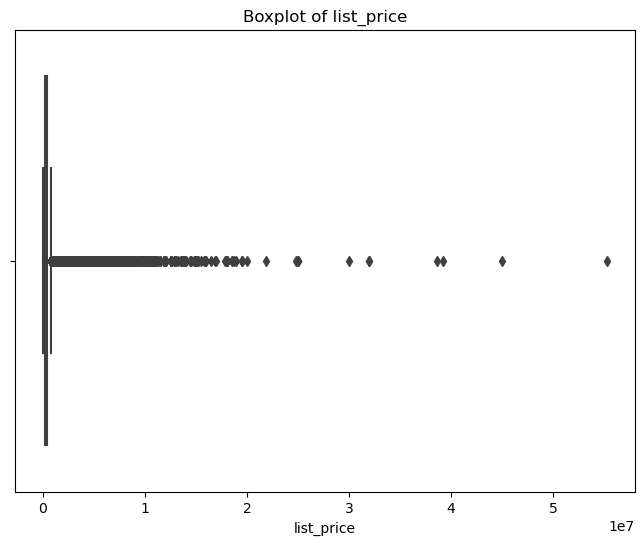

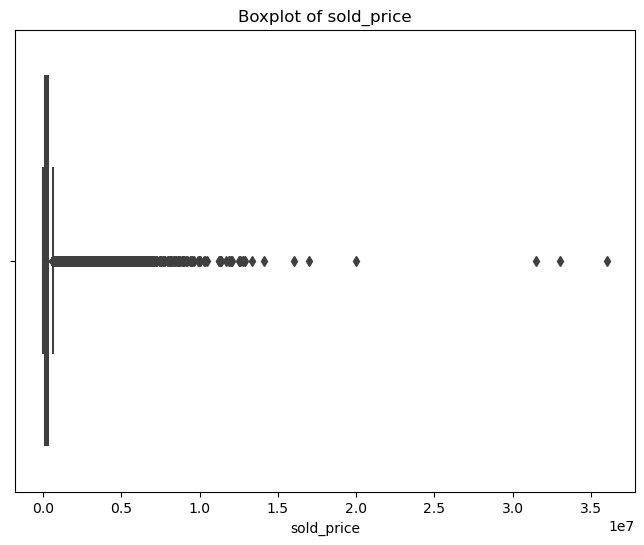

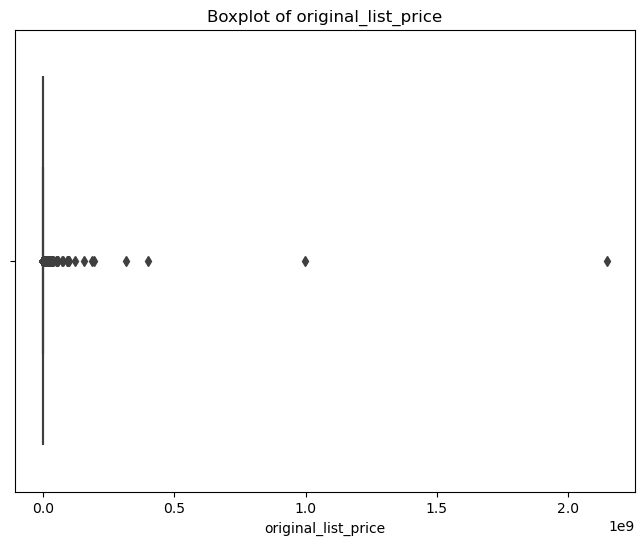

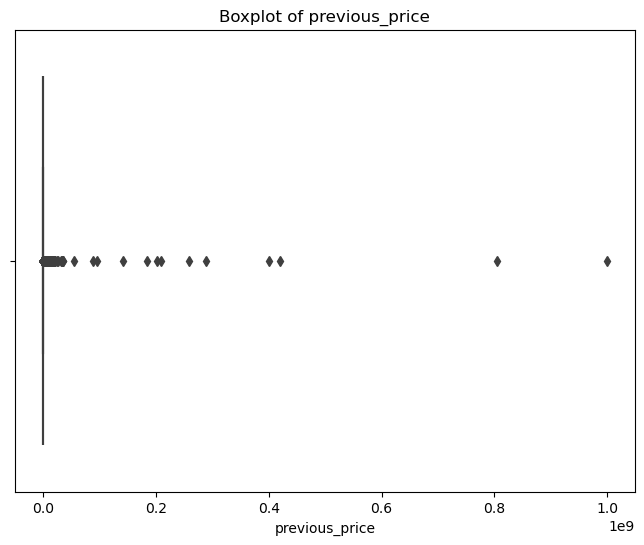

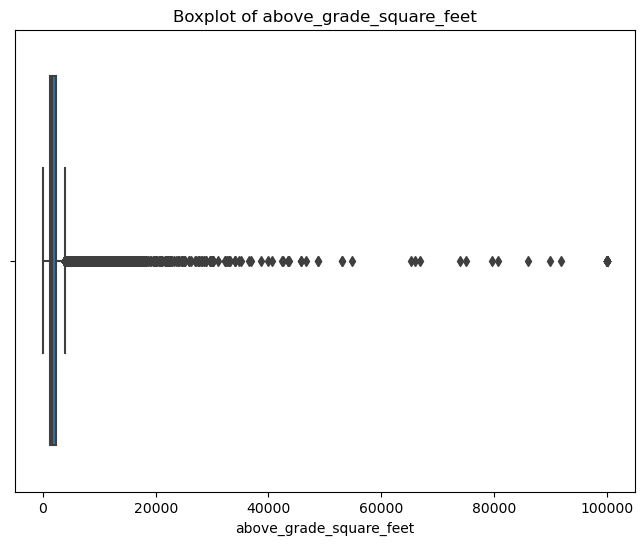

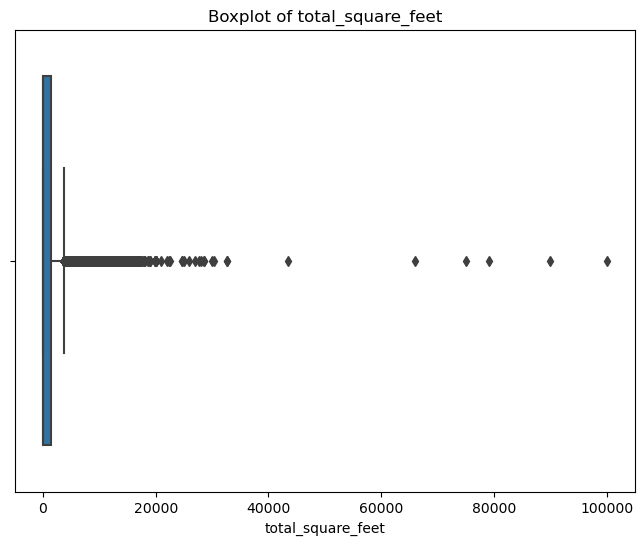

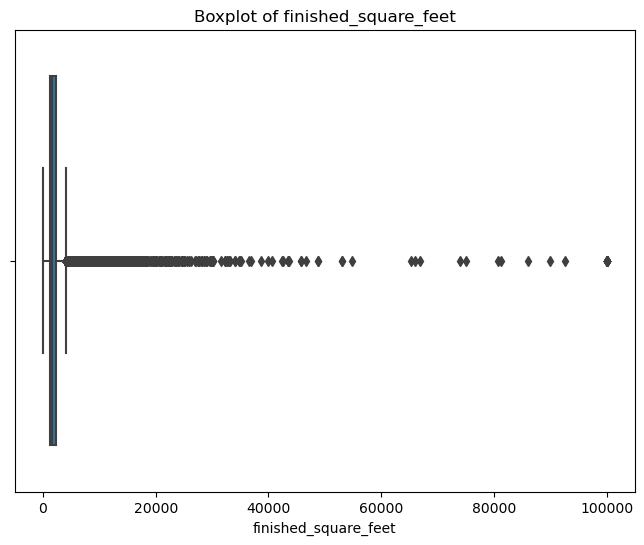

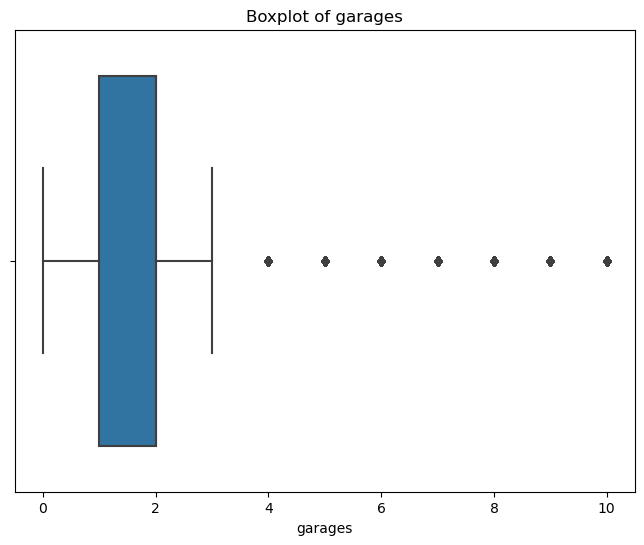

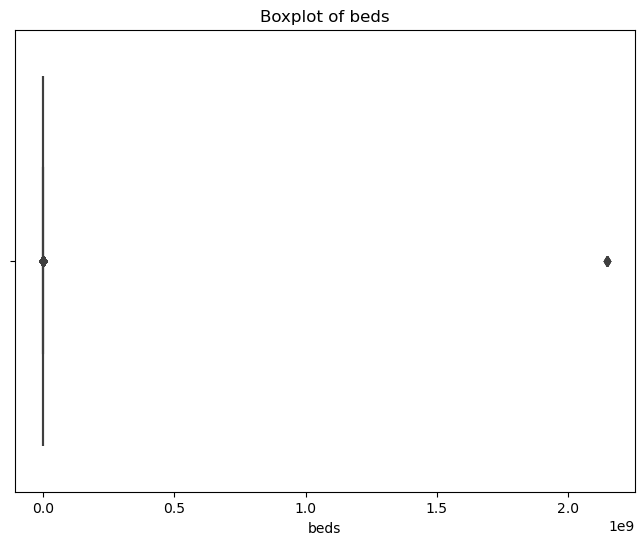

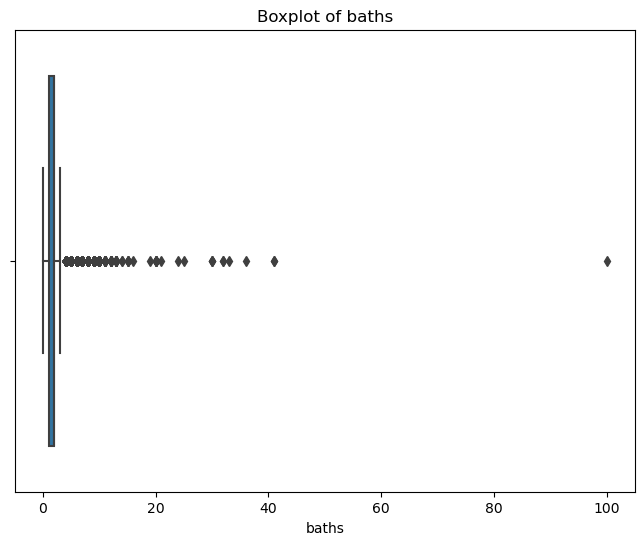

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Check outliers
cols_to_check = ['list_price', 'sold_price', 'original_list_price',
                'previous_price','above_grade_square_feet', 'total_square_feet', 
                 'finished_square_feet', 'garages', 'beds', 'baths']

# Draw box plot
for col in cols_to_check:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=df1[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [25]:
# Check for extremely large values in the 'beds' column (greater than 2.0e9)
print(df1[df1['beds'] > 2.0e9])

              id  property_id  listing_number status_changed_on  \
364149    502464          NaN         9449155        2011-02-25   
424835    563150      18542.0         9415793        2003-07-01   
427589    565904      15548.0         9415252        2002-08-05   
1402831  1541226    1022508.0        11097069        2021-06-22   
1408714  1547112    1025770.0        11100387        2021-09-17   
1411025  1549423     529238.0        11040313        2021-06-07   
1419259  1557660     816004.0        11066394        2021-06-21   

                  created_at           updated_at    status   listed_on  \
364149   2018-09-21 16:08:43  2020-12-29 07:24:18      sold  2009-04-23   
424835   2018-09-21 17:59:50  2020-12-29 07:49:43      sold  2003-05-02   
427589   2018-09-21 18:04:46  2020-12-29 07:47:10      sold  2002-07-19   
1402831  2021-06-02 19:30:24  2021-06-22 14:00:15  inactive  2021-06-02   
1408714  2021-06-09 15:30:22  2022-09-08 00:00:08      sold  2021-06-09   
1411025  2021

In [27]:
# Calculate the median value of 'beds'
median_beds = df1['beds'].median()

# Replace outlier values with the median
df1['beds'] = df1['beds'].apply(lambda x: median_beds if x > 2.0e9 else x)

# Check the data again after handling the outliers
print(df1['beds'].describe())

count    1.687109e+06
mean     3.101290e+00
std      1.237686e+00
min      0.000000e+00
25%      2.000000e+00
50%      3.000000e+00
75%      4.000000e+00
max      8.900000e+01
Name: beds, dtype: float64


In [29]:
# Replace unusually high max values (max: 89) with a reasonable value
df1['beds'] = df1['beds'].apply(lambda x: 10 if x > 10 else x)

# Check the results again with describe()
print(df1['beds'].describe())

count    1.687109e+06
mean     3.098793e+00
std      1.218121e+00
min      0.000000e+00
25%      2.000000e+00
50%      3.000000e+00
75%      4.000000e+00
max      1.000000e+01
Name: beds, dtype: float64


In [31]:
# Fill NaN values of 'beds' column with median
df1['beds'] = df1['beds'].fillna(df1['beds'].median())

print(df1[['beds']].isna().sum())

beds    0
dtype: int64


In [33]:
# Check rows with baths value = 100 (Boxplot)
print(df1.loc[df1['baths'] == 100, 'baths'])

990267    100.0
Name: baths, dtype: float64


In [35]:
# Replace with median
median_baths = df1['baths'].median()
df1['baths'] = df1['baths'].apply(lambda x: median_baths if x == 100 else x)

# Check the result again with describe
print(df1['baths'].describe())

count    1.687909e+06
mean     1.947516e+00
std      9.144151e-01
min      0.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      2.000000e+00
max      4.100000e+01
Name: baths, dtype: float64


In [37]:
# Filter rows with 'baths' value > 10 to check for outliers
print(df1.loc[df1['baths'] > 10, 'baths'])

4867       13.0
13710      13.0
17020      11.0
43765      12.0
93019      15.0
107358     11.0
116225     36.0
167414     13.0
209984     13.0
210826     41.0
223223     41.0
257152     14.0
263253     11.0
277505     21.0
282140     12.0
321682     20.0
326539     14.0
371797     15.0
422147     11.0
423295     20.0
496192     11.0
556522     12.0
701950     11.0
713749     24.0
748326     15.0
755448     20.0
756613     20.0
817932     12.0
823095     25.0
854265     13.0
911810     11.0
968961     12.0
990348     15.0
990358     30.0
990363     16.0
990472     30.0
990489     30.0
1127062    12.0
1128721    12.0
1196176    13.0
1223127    12.0
1253259    20.0
1290573    11.0
1297313    20.0
1323418    11.0
1343031    32.0
1382726    32.0
1390688    11.0
1395257    12.0
1396055    11.0
1407211    12.0
1416590    13.0
1435974    13.0
1515804    13.0
1543835    11.0
1557925    11.0
1576060    11.0
1620262    19.0
1638510    13.0
1643891    11.0
1666781    12.0
1682802    33.0
1684415 

In [39]:
# Replace unusually high max values (max: 41) with a reasonable value
df1['baths'] = df1['baths'].apply(lambda x: 10 if x > 10 else x)

# Check the results again with describe()
print(df1['baths'].describe())

count    1.687909e+06
mean     1.947264e+00
std      9.099672e-01
min      0.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      2.000000e+00
max      1.000000e+01
Name: baths, dtype: float64


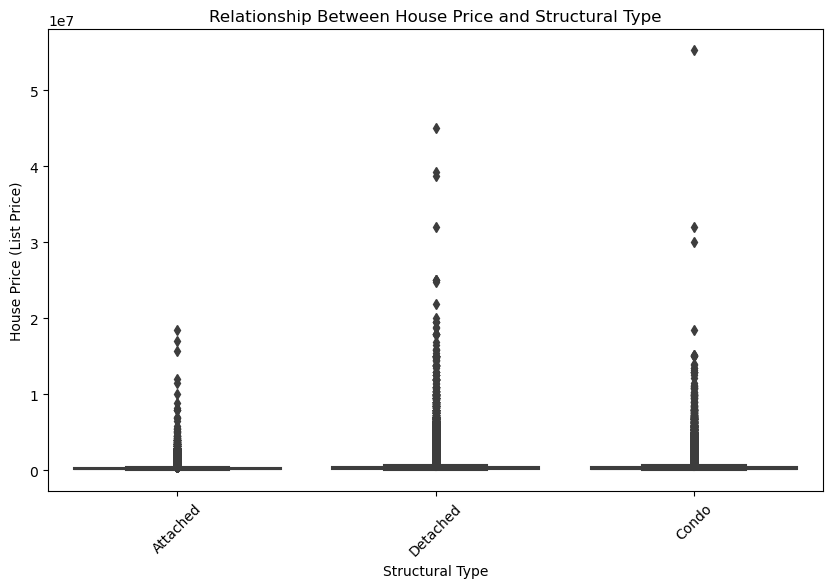

In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize the relationship between 'list_price' and 'structural_type' using a boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='structural_type', y='list_price', data=df1)  # Use 'data' instead of 'data1'
plt.title('Relationship Between House Price and Structural Type')
plt.xlabel('Structural Type')
plt.ylabel('House Price (List Price)')
plt.xticks(rotation=45)
plt.show()

In [43]:
df1["structural_type"].value_counts()

structural_type
Detached    1102801
Condo        374205
Attached     219375
Name: count, dtype: int64

In [45]:
import pandas as pd

# Filter rows where 'structural_type' value is 'Attached and 'list_price' > 1.5e7
attached_high_price = df1[(df1['structural_type'] == 'Attached') & (df1['list_price'] > 1e7)]

attached_high_price[['id','list_price', 'structural_type', 'zip']]

,id,list_price,structural_type,zip
998457,1136772,11500000.0,Attached,60611
1286620,1424963,17000000.0,Attached,60610
1353825,1492195,18484900.0,Attached,60440
1487740,1626163,12000000.0,Attached,60610
1667247,1805744,15750000.0,Attached,60611


                   list_price      area  total_square_feet      beds  \
list_price           1.000000 -0.642151                NaN -0.013477   
area                -0.642151  1.000000                NaN  0.612372   
total_square_feet         NaN       NaN                NaN       NaN   
beds                -0.013477  0.612372                NaN  1.000000   
baths               -0.259104  0.825593                NaN  0.951662   
garages             -0.351524       NaN                NaN -0.777778   

                      baths   garages  
list_price        -0.259104 -0.351524  
area               0.825593       NaN  
total_square_feet       NaN       NaN  
beds               0.951662 -0.777778  
baths              1.000000 -0.777778  
garages           -0.777778  1.000000  


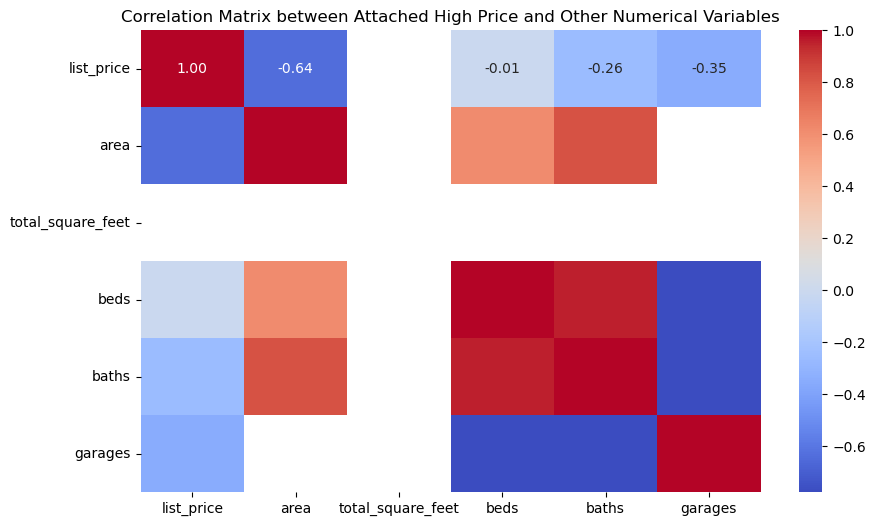

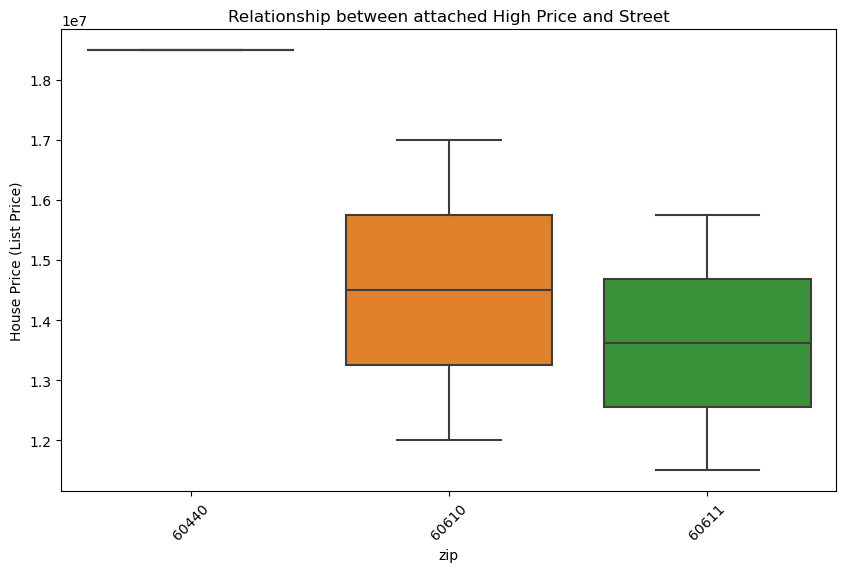

In [47]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming attached_high_price is a filtered DataFrame like below:
attached_high_price = df1[(df1['structural_type'] == 'Attached') & (df1['list_price'] > 1e7)]

# 1. Relationship between 'attached_high_price' and numerical columns
# Calculate the correlation between list_price and other numerical columns
correlation_matrix = attached_high_price[['list_price', 'area', 'total_square_feet', 'beds', 'baths', 'garages']].corr()
print(correlation_matrix)

# Display the heatmap of the correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix between Attached High Price and Other Numerical Variables')
plt.show()

#+1: The two variables have a very strong relationship, increasing together (e.g: baths increase => beds increase)
#-1: The two variables have a very strong relationship, but in opposite directions (e.g: list_price increase => beds decrease)
# 0: There is no linear relationship between the two variables.

# 2. Visualize the relationship between list_price and zip (boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(x='zip', y='list_price', data=attached_high_price)
plt.title('Relationship between attached High Price and Street')
plt.xlabel('zip')
plt.ylabel('House Price (List Price)')
plt.xticks(rotation=45)
plt.show()

In [49]:
import pandas as pd

# Filter rows where 'structural_type' value is 'Detached' and 'list_price' > 2.5e7
detached_high_price = df1[(df1['structural_type'] == 'Detached') & (df1['list_price'] > 2.5e7)]

detached_high_price[['id', 'list_price', 'structural_type']] 

,id,list_price,structural_type
205069,343384,45000000.0,Detached
1211450,1349769,38670500.0,Detached
1317538,1455894,32000000.0,Detached
1511075,1649510,39250000.0,Detached


                   list_price      area  total_square_feet      beds  baths  \
list_price           1.000000 -0.040274                1.0  0.424163   -1.0   
area                -0.040274  1.000000                1.0 -0.055475   -1.0   
total_square_feet    1.000000  1.000000                1.0 -1.000000   -1.0   
beds                 0.424163 -0.055475               -1.0  1.000000    1.0   
baths               -1.000000 -1.000000               -1.0  1.000000    1.0   
garages             -1.000000 -1.000000               -1.0  1.000000    1.0   

                   garages  
list_price            -1.0  
area                  -1.0  
total_square_feet     -1.0  
beds                   1.0  
baths                  1.0  
garages                1.0  


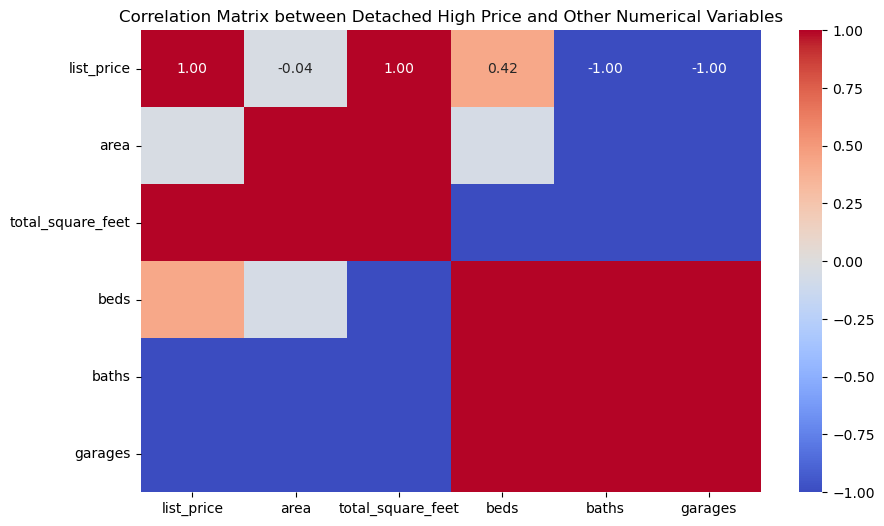

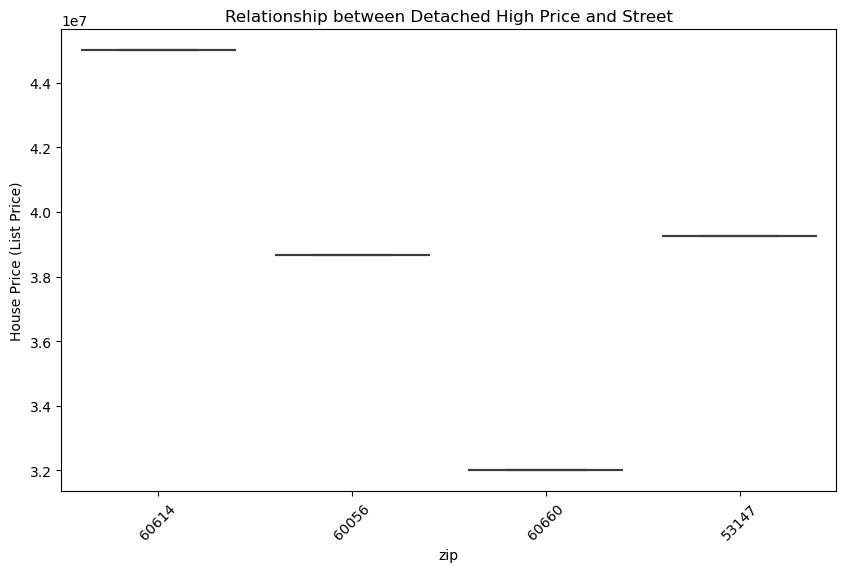

In [51]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming detached_high_price is a filtered DataFrame like below:
detached_high_price = df1[(df1['structural_type'] == 'Detached') & (df1['list_price'] > 2.5e7)]

# 1. Relationship between 'detached_high_price' and numerical columns
# Calculate the correlation between list_price and other numerical columns
correlation_matrix = detached_high_price[['list_price', 'area', 'total_square_feet', 'beds', 'baths', 'garages']].corr()
print(correlation_matrix)

# Display the heatmap of the correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix between Detached High Price and Other Numerical Variables')
plt.show()

#+1: The two variables have a very strong relationship, increasing together (e.g: baths increase => beds increase)
#-1: The two variables have a very strong relationship, but in opposite directions (e.g: list_price increase => beds decrease)
# 0: There is no linear relationship between the two variables.

# 2. Visualize the relationship between list_price and zip (boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(x='zip', y='list_price', data=detached_high_price)
plt.title('Relationship between Detached High Price and Street')
plt.xlabel('zip')
plt.ylabel('House Price (List Price)')
plt.xticks(rotation=45)
plt.show()

In [53]:
import pandas as pd

# Filter rows where 'structural_type' value is 'Condo' and 'list_price' > 1.5e7
condo_high_price = df1[(df1['structural_type'] == 'Condo') & (df1['list_price'] > 1.5e7)]

condo_high_price[['id', 'list_price', 'structural_type']] 

,id,list_price,structural_type
26407,164722,18500000.0,Condo
622753,761068,32000000.0,Condo
953647,1091962,15174000.0,Condo
1123938,1262255,55270000.0,Condo
1371262,1509641,15170000.0,Condo
1484759,1623181,30000000.0,Condo


                   list_price      area  total_square_feet      beds  \
list_price           1.000000  0.463372           0.137441 -0.362048   
area                 0.463372  1.000000          -0.316228 -0.685994   
total_square_feet    0.137441 -0.316228           1.000000  0.542326   
beds                -0.362048 -0.685994           0.542326  1.000000   
baths                0.166944 -0.500000           0.632456  0.857493   
garages             -0.006546 -0.707107           0.745356  0.889297   

                      baths   garages  
list_price         0.166944 -0.006546  
area              -0.500000 -0.707107  
total_square_feet  0.632456  0.745356  
beds               0.857493  0.889297  
baths              1.000000  0.942809  
garages            0.942809  1.000000  


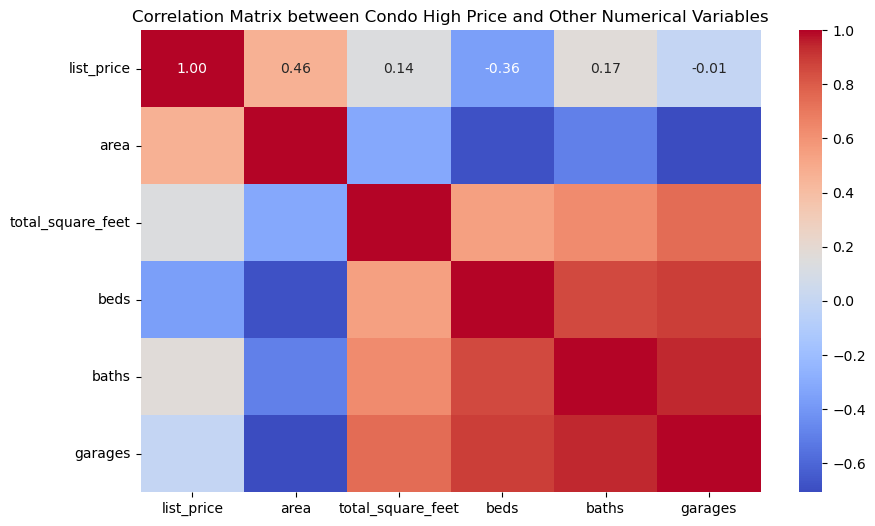

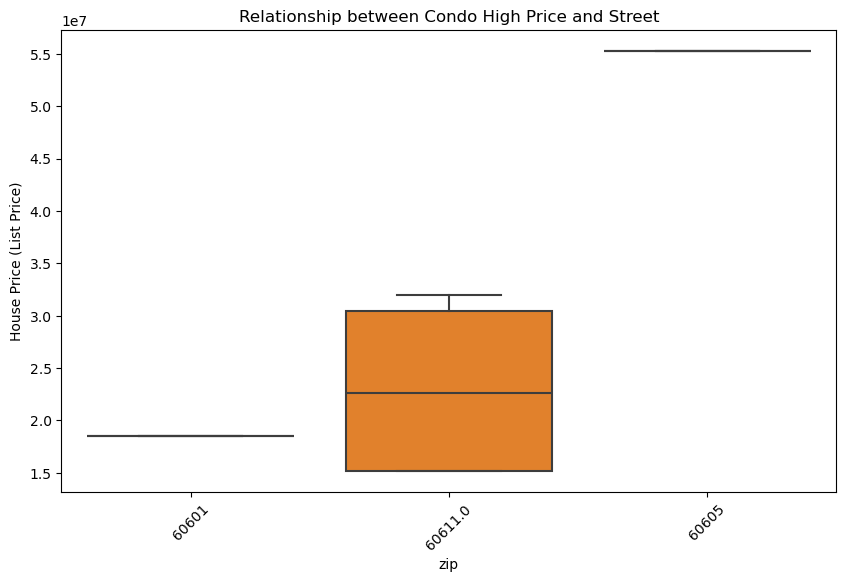

In [55]:
# Assuming detached_high_price is a filtered DataFrame like below:
condo_high_price = df1[(df1['structural_type'] == 'Condo') & (df1['list_price'] > 1.5e7)]

# 1. Relationship between 'detached_high_price' and numerical columns
# Calculate the correlation between list_price and other numerical columns
correlation_matrix = condo_high_price[['list_price', 'area', 'total_square_feet', 'beds', 'baths', 'garages']].corr()
print(correlation_matrix)

# Display the heatmap of the correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix between Condo High Price and Other Numerical Variables')
plt.show()

#+1: The two variables have a very strong relationship, increasing together (e.g: baths increase => beds increase)
#-1: The two variables have a very strong relationship, but in opposite directions (e.g: list_price increase => beds decrease)
# 0: There is no linear relationship between the two variables.

# 2. Visualize the relationship between list_price and zip (boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(x='zip', y='list_price', data=condo_high_price)
plt.title('Relationship between Condo High Price and Street')
plt.xlabel('zip')
plt.ylabel('House Price (List Price)')
plt.xticks(rotation=45)
plt.show()

In [57]:
df1["status"].value_counts()

status
sold              1297859
inactive           357738
active              23013
under-contract      13565
pending              4206
Name: count, dtype: int64

In [59]:
# Check for NaN values
print(df1['status'].isnull().sum())

0


In [61]:
# Filter for sold homes (status is "sold")
sold_houses = df1[df1['status'] == 'sold']

In [63]:
# Filter unsold homes (status is not "sold")
not_sold_houses = df1[df1['status'] != 'sold']

In [65]:
# Filter rows with sold_price > 1.5 * 1e7 (Boxplot)
filtered_data = df1[df1['sold_price'] > 1.5 * 1e7]

print(filtered_data[['sold_price']])

         sold_price
390720   16000000.0
622753   17000000.0
1211450  33000000.0
1317538  31500000.0
1484759  20000000.0
1511075  36000000.0


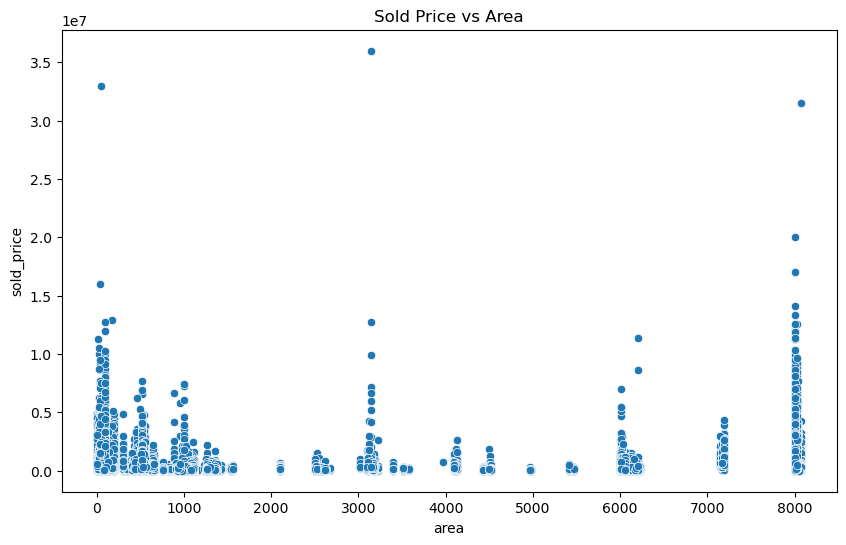

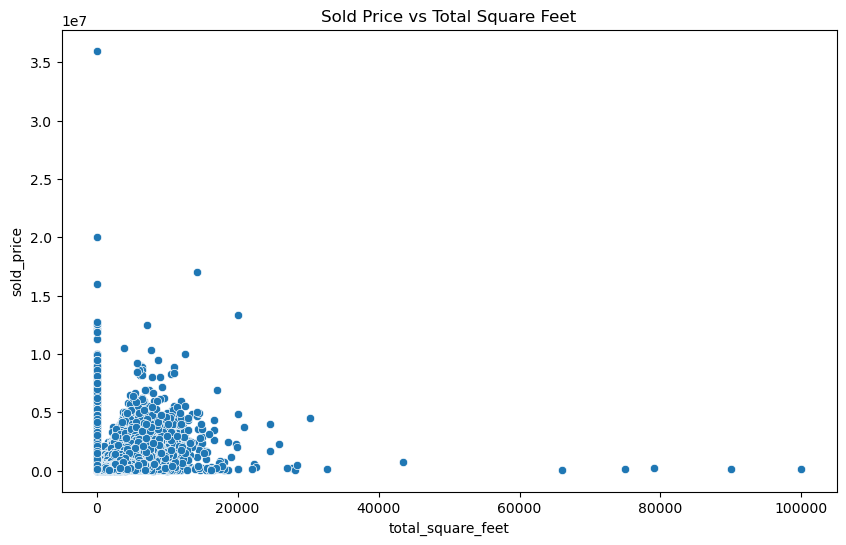

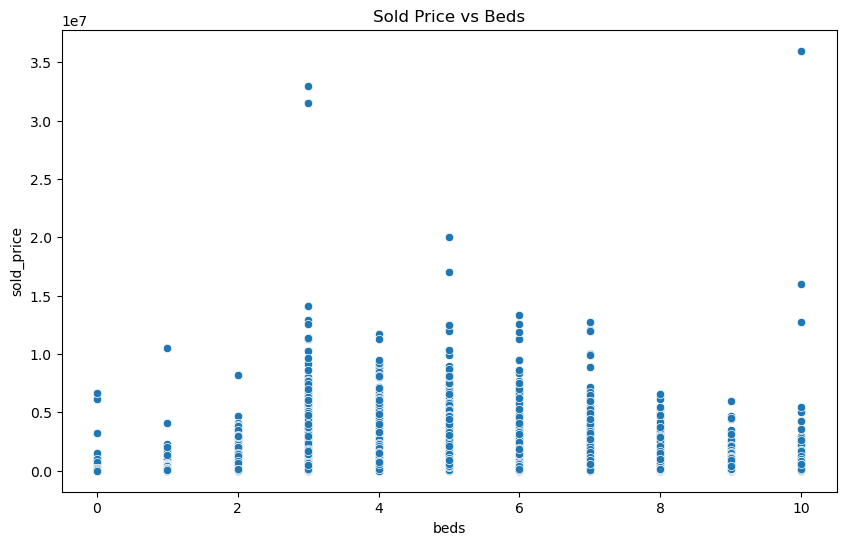

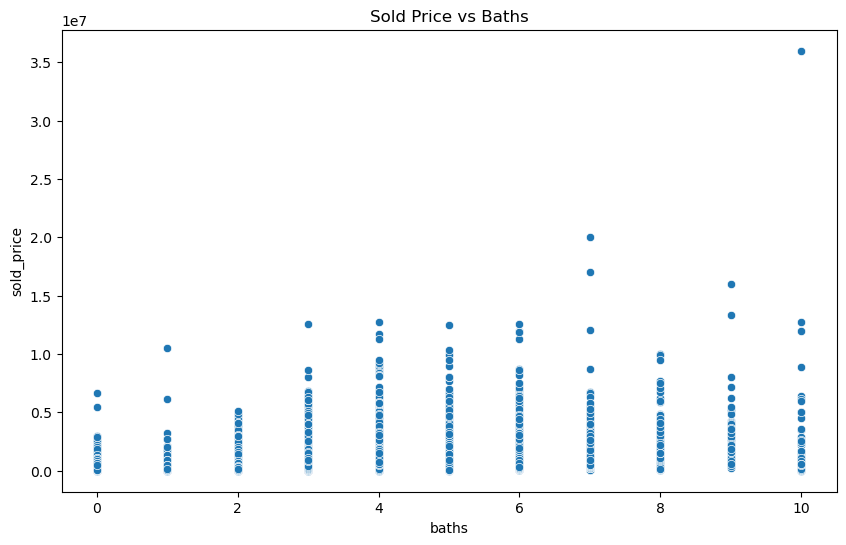

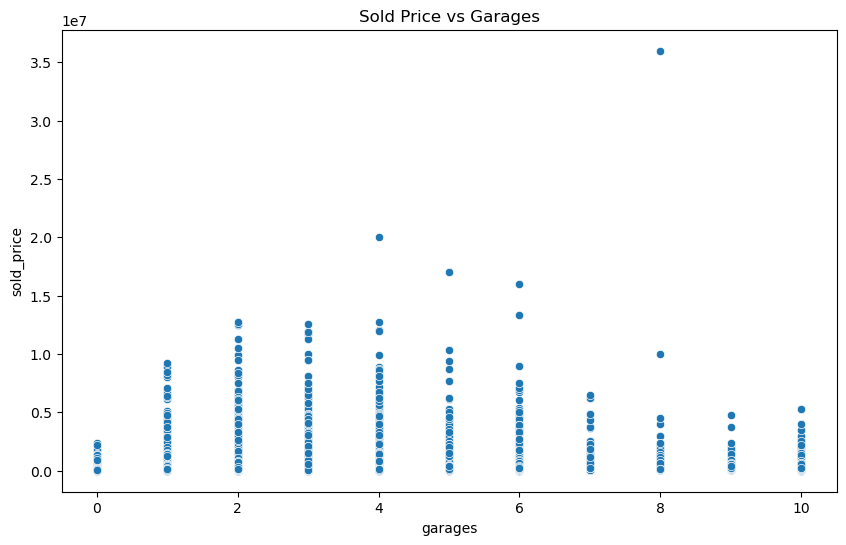

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

# Scatter plot between 'sold_price' and 'area'
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df1, x='area', y='sold_price')
plt.title('Sold Price vs Area')
plt.show()

# Scatter plot between 'sold_price' and 'total_square_feet'
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df1, x='total_square_feet', y='sold_price')
plt.title('Sold Price vs Total Square Feet')
plt.show()

# Scatter plot between 'sold_price' and 'beds'
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df1, x='beds', y='sold_price')
plt.title('Sold Price vs Beds')
plt.show()

# Scatter plot between 'sold_price' and 'baths'
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df1, x='baths', y='sold_price')
plt.title('Sold Price vs Baths')
plt.show()

# Scatter plot between 'sold_price' and 'garages'
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df1, x='garages', y='sold_price')
plt.title('Sold Price vs Garages')
plt.show()


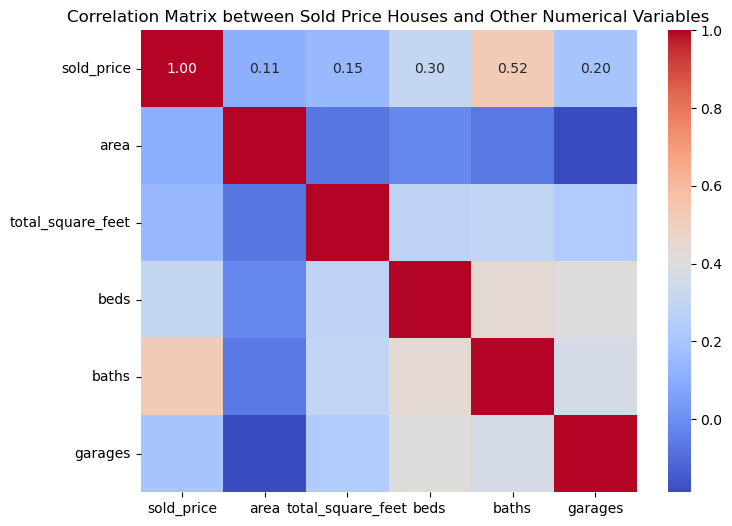

In [69]:
#Display the heatmap of the correlation matrix
correlation_matrix = df1[['sold_price', 'area', 'total_square_feet', 'beds', 'baths', 'garages']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix between Sold Price Houses and Other Numerical Variables')
plt.show()

In [71]:
# Represent unique identifiers =>  cannot be reliably processed or analyzed => Drop NaN values 
df1.dropna(subset=['id', 'property_id', 'listing_number', 'property_key'], inplace=True)

In [73]:
df1.drop(columns = ['property_id', 'id', 'listing_number', 'created_at','status_changed_on','updated_at', 'sold_on', 'listed_on', 
                    'contracted_on', 'off_market_on', 'previous_price', 'property_key', 'externally_last_updated_at'], inplace = True)

In [75]:
# Calculate the average value of 'sold_price' for each 'zip'
avg_sold_price_by_zip = df1.groupby('zip')['sold_price'].median()

# Fill in NaN valuesin the 'sold_price' column
df1['sold_price'] = df1['sold_price'].fillna(df1['zip'].map(avg_sold_price_by_zip))

In [77]:
# Calculate the average value of 'sold_price' for each 'street'
avg_sold_price_by_street = df1.groupby('street')['sold_price'].median()

# Fill in NaN valuesin the 'sold_price' column
df1['sold_price'] = df1['sold_price'].fillna(df1['street'].map(avg_sold_price_by_street))

In [79]:
# Calculate the average value of 'sold_price' for each 'county'
avg_sold_price_by_county = df1.groupby('county')['sold_price'].median()

# Fill in NaN valuesin the 'sold_price' column
df1['sold_price'] = df1['sold_price'].fillna(df1['county'].map(avg_sold_price_by_county))

In [81]:
# Calculate the average value of 'sold_price' for each 'baths'
avg_sold_price_by_baths = df1.groupby('baths')['sold_price'].median()

# Fill in NaN valuesin the 'sold_price' column
df1['sold_price'] = df1['sold_price'].fillna(df1['baths'].map(avg_sold_price_by_baths))

In [83]:
# Calculate the average value of 'sold_price' for each 'baths'
avg_sold_price_by_baths = df1.groupby('baths')['sold_price'].median()

# Fill in NaN valuesin the 'sold_price' column
df1['sold_price'] = df1['sold_price'].fillna(df1['baths'].map(avg_sold_price_by_baths))

In [85]:
nan_rows = df1[df1['sold_price'].isna()]
print(nan_rows)

           status  list_price  sold_price  original_list_price  \
1209459  inactive    195000.0         NaN             195000.0   

         above_grade_square_feet  total_square_feet  finished_square_feet  \
1209459                      NaN                NaN                   NaN   

        car_storage  garages  beds  baths   area subdivision           street  \
1209459         NaN      NaN   3.0    NaN  982.0         NaN  2943 W 300 S ST   

         city state    zip county  photos  photos_pulled structural_style  \
1209459  Peru    IN  46970    NaN       1            1.0              NaN   

        property_type architecture  year_built  lot_size_square_feet  \
1209459  Multi-family          NaN      1970.0                   NaN   

         lot_size_acres  basement_finished_pct  basement_square_feet  \
1209459             NaN                    NaN                   NaN   

         basement_size  basement_type  seller_type  \
1209459            NaN            NaN          NaN

In [87]:
# Calculate the average value of 'sold_price' for each 'state'
avg_sold_price_by_state = df1.groupby('state')['sold_price'].median()

# Fill in NaN valuesin the 'sold_price' column
df1['sold_price'] = df1['sold_price'].fillna(df1['state'].map(avg_sold_price_by_state))

In [89]:
# Convert sold_price value to integer (int)
df1['sold_price'] = df1['sold_price'].astype(int)

In [91]:
# Calculate the average value of 'list_price' for each 'zip'
avg_list_price_by_zip = df1.groupby('zip')['list_price'].median()

# Fill in NaN valuesin the 'list_price' column
df1['list_price'] = df1['list_price'].fillna(df1['zip'].map(avg_list_price_by_zip))

In [93]:
# Calculate the average value of 'original_list_price' for each 'zip'
avg_org_list_price_by_zip = df1.groupby('zip')['original_list_price'].median()

# Fill in NaN valuesin the 'original_list_price' column
df1['original_list_price'] = df1['original_list_price'].fillna(df1['zip'].map(avg_org_list_price_by_zip))

In [95]:
# Calculate the average value of 'original_list_price' for each 'street'
avg_org_list_price_by_street = df1.groupby('street')['original_list_price'].median()

# Fill in NaN valuesin the 'original_list_price' column
df1['original_list_price'] = df1['original_list_price'].fillna(df1['street'].map(avg_org_list_price_by_street))

In [97]:
# Calculate the average value of 'original_list_price' for each 'county'
avg_org_list_price_by_county = df1.groupby('county')['original_list_price'].median()

# Fill in NaN valuesin the 'original_list_price' column
df1['original_list_price'] = df1['original_list_price'].fillna(df1['county'].map(avg_org_list_price_by_county))

In [99]:
# Calculate the average value of 'sold_price' for each 'baths'
avg_org_list_price_by_baths = df1.groupby('baths')['original_list_price'].median()

# Fill in NaN valuesin the 'original_list_price' column
df1['original_list_price'] = df1['original_list_price'].fillna(df1['baths'].map(avg_org_list_price_by_baths))

In [101]:
median_value = df1['above_grade_square_feet'].median()

# Fill NaN values with median 
df1['above_grade_square_feet'] = df1['above_grade_square_feet'].fillna(median_value)

In [103]:
median_value = df1['total_square_feet'].median()

# Fill NaN values with median 
df1['total_square_feet'] = df1['total_square_feet'].fillna(median_value)

In [105]:
median_value = df1['finished_square_feet'].median()

# Fill NaN values with median 
df1['finished_square_feet'] = df1['finished_square_feet'].fillna(median_value)

In [107]:
# Fill NaN values with 0 (no parking)
df1['car_storage'] = df1['car_storage'].fillna(0)


In [109]:
# Fill NaN values with 0 (no parking)
df1['car_storage'] = df1['car_storage'].fillna(0)

In [111]:
# Fill NaN values with 0 (no garage)
df1['garages'] = df1['garages'].fillna(0)

In [113]:
# Fill NaN values with 0 (no bath)
df1['baths'] = df1['baths'].fillna(0)

In [116]:
# Fill NaN values with 'total_square_feet'
df1['area'] = df1.apply(
    lambda row: row['total_square_feet'] if pd.isna(row['area']) else row['area'],
    axis=1
)

In [118]:
import pandas as pd
mode_value = df1['subdivision'].mode()[0]
df1['subdivision'].fillna(mode_value, inplace=True)
df1['city'].fillna(df1['city'].mode()[0], inplace=True)
df1['state'].fillna(df1['state'].mode()[0], inplace=True)
df1['zip'].fillna(df1['zip'].mode()[0], inplace=True)
df1['county'].fillna(df1['county'].mode()[0], inplace=True)

In [120]:
# Check the NaN values of all columns
df1.isna().sum()

status                           0
list_price                       0
sold_price                       0
original_list_price              0
above_grade_square_feet          0
total_square_feet                0
finished_square_feet             0
car_storage                      0
garages                          0
beds                             0
baths                            0
area                             0
subdivision                      0
street                           0
city                             0
state                            0
zip                              0
county                           0
photos                           0
photos_pulled               227610
structural_style             91275
property_type                    0
architecture               1033546
year_built                   35348
lot_size_square_feet        618795
lot_size_acres              639998
basement_finished_pct      1532299
basement_square_feet       1409830
basement_size       

In [122]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1639775 entries, 0 to 1696380
Data columns (total 52 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   status                   1639775 non-null  object 
 1   list_price               1639775 non-null  float64
 2   sold_price               1639775 non-null  int32  
 3   original_list_price      1639775 non-null  float64
 4   above_grade_square_feet  1639775 non-null  float64
 5   total_square_feet        1639775 non-null  float64
 6   finished_square_feet     1639775 non-null  float64
 7   car_storage              1639775 non-null  object 
 8   garages                  1639775 non-null  float64
 9   beds                     1639775 non-null  float64
 10  baths                    1639775 non-null  float64
 11  area                     1639775 non-null  float64
 12  subdivision              1639775 non-null  object 
 13  street                   1639775 non-null  obje

In [124]:
print(df1.shape)

(1639775, 52)


In [127]:
df1.to_csv('df1.csv', index = False)
print('Cleanned data has been saved to "df1.csv".')
#Can't use only Chicago data in data1 but have to use all (tried filtering but too little data left)

Cleanned data has been saved to "df1.csv".


In [7]:
import pandas as pd

file_path = 'df1.csv'

chunk_size = 10000  
data_chunks = []   

try:
    for chunk in pd.read_csv(file_path, chunksize=chunk_size):
        data_chunks.append(chunk)
    
    df = pd.concat(data_chunks, ignore_index=True)
    
    print(f"Full table loaded successfully with {df.shape[0]} rows and {df.shape[1]} columns.")
    
    display(df)
    
except StopIteration:
    print("The file is empty or smaller than the defined chunk size.")
except Exception as e:
    print(f"Error reading file: {e}")

pd.set_option('display.max_rows', None)  
pd.set_option('display.max_columns', None)  

data2 = df

Full table loaded successfully with 1639775 rows and 52 columns.


,status,list_price,sold_price,original_list_price,above_grade_square_feet,total_square_feet,finished_square_feet,car_storage,garages,beds,...,stories,version,parcel_number,hoa_name,hoa_fee,school_district,private_remarks,price_changes,unit_count,county_data_id
0,sold,19100.0,20154,19100.0,1096.0,1096.0,1096.0,0,1.0,2.0,...,2,NaN,25033110370000,NaN,0.0,NaN,"Visit HUBZU.COM for minimum bid amounts, & sta...","{""sold"":{""2016-09-19"":20154},""active"":{""2016-0...",NaN,45065073.0
1,sold,289900.0,274000,315000.0,2703.0,2703.0,2703.0,"Garage Door Opener(s), Transmitter(s)",3.0,4.0,...,2,NaN,0630153005,NaN,50.0,NaN,Per the county. Taxes on this property without...,"{""sold"":{""2016-07-26"":274000},""active"":{""2016-...",NaN,46229317.0
2,sold,109900.0,108900,269900.0,2000.0,2000.0,2000.0,0,0.0,3.0,...,1,NaN,032025180015,NaN,0.0,NaN,NaN,"{""sold"":{""1998-10-30"":108900},""active"":{""1998-...",NaN,43302176.0
3,sold,64500.0,60000,124900.0,1170.0,1170.0,1170.0,0,0.0,3.0,...,1,NaN,090234207018,NaN,0.0,NaN,NaN,"{""sold"":{""1998-10-30"":60000},""active"":{""1998-0...",NaN,45438113.0
4,sold,90000.0,81000,269900.0,1509.0,1509.0,1509.0,0,0.0,3.0,...,1,NaN,192723301014,NaN,0.0,NaN,NaN,"{""sold"":{""1998-12-07"":81000},""active"":{""1998-0...",NaN,43328065.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1639770,active,339900.0,450539,339900.0,1000.0,0.0,1000.0,0,0.0,3.0,...,1,NaN,13241120160000,NaN,NaN,NaN,"Earnest money to be held by listing office, ca...","{""active"":{""2022-09-09"":339900}}",NaN,44040951.0
1639771,active,1229000.0,425000,1229000.0,3934.0,3934.0,5534.0,"Garage Door Opener(s), Transmitter(s)",3.0,4.0,...,2,NaN,11083100150000,NaN,300.0,NaN,Wineberry offers an active homeowner's associa...,"{""active"":{""2022-09-09"":1229000}}",NaN,46717465.0
1639772,active,315000.0,474000,315000.0,1200.0,0.0,1200.0,Assigned Spaces,0.0,2.0,...,3,NaN,13261310160000,NaN,251.0,NaN,"New Appliances 2016, New Roof 2019, Tuckpointi...","{""active"":{""2022-09-09"":315000}}",9.0,-1.0
1639773,active,599000.0,205000,599000.0,3000.0,0.0,3000.0,"Garage Door Opener(s), Transmitter(s), 7 Foot ...",1.0,4.0,...,3,NaN,20102100230000,NaN,150.0,NaN,All offers must be submitted on Developers Pur...,"{""active"":{""2022-09-09"":599000}}",6.0,-1.0


In [9]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1639775 entries, 0 to 1639774
Data columns (total 52 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   status                   1639775 non-null  object 
 1   list_price               1639775 non-null  float64
 2   sold_price               1639775 non-null  int64  
 3   original_list_price      1639775 non-null  float64
 4   above_grade_square_feet  1639775 non-null  float64
 5   total_square_feet        1639775 non-null  float64
 6   finished_square_feet     1639775 non-null  float64
 7   car_storage              1639775 non-null  object 
 8   garages                  1639775 non-null  float64
 9   beds                     1639775 non-null  float64
 10  baths                    1639775 non-null  float64
 11  area                     1639775 non-null  float64
 12  subdivision              1639775 non-null  object 
 13  street                   1639775 non-null 

In [11]:
nan_counts = data2.isna().sum()
print(nan_counts)

status                           0
list_price                       0
sold_price                       0
original_list_price              0
above_grade_square_feet          0
total_square_feet                0
finished_square_feet             0
car_storage                      0
garages                          0
beds                             0
baths                            0
area                             0
subdivision                      0
street                           0
city                             0
state                            0
zip                              0
county                           0
photos                           0
photos_pulled               227610
structural_style             91275
property_type                    0
architecture               1033546
year_built                   35348
lot_size_square_feet        618795
lot_size_acres              639998
basement_finished_pct      1532299
basement_square_feet       1409830
basement_size       

In [15]:
# Drop the columns with > 75% NaN values 
data2 = data2.copy()

data2.drop(
    columns=[
        "basement_size", "basement_type", "seller_type", "showings_phone", "approval_condition", "version", "hoa_name", "school_district", "zoned", "basement_finished_pct", "basement_square_feet", "unit_count"
    ], 
    errors='ignore',
    inplace=True
)

# note cua anh chi
data2.drop(
    columns=['public_remarks', 'photos_pulled', 'description', 'private_remarks'], 
    errors='ignore',
    inplace=True
)

In [17]:
columns_to_describe = [
'photos', 'photos_pulled', 'structural_style', 'property_type', 'architecture', 'year_built', 'lot_size_square_feet', 'lot_size_acres', 'description', 'lat'
]

# Check if all columns are present to avoid KeyError
existing_columns = [col for col in columns_to_describe if col in data2.columns]

data2_subset = data2[existing_columns].describe(include='all')
display(data2_subset)

,photos,structural_style,property_type,architecture,year_built,lot_size_square_feet,lot_size_acres,lat
count,1.639775e+06,1548500,1639775,606229,1.604427e+06,1.020980e+06,9.997770e+05,1.639775e+06
unique,NaN,959,5,393,NaN,NaN,NaN,NaN
top,NaN,Condo,Detached Single,Ranch,NaN,NaN,NaN,NaN
freq,NaN,650396,986696,197667,NaN,NaN,NaN,NaN
mean,1.840263e+01,NaN,NaN,NaN,1.845641e+03,6.445921e+04,1.098223e+04,4.175997e+01
std,1.234521e+01,NaN,NaN,NaN,4.836975e+02,9.601088e+06,1.001939e+07,5.706462e-01
min,0.000000e+00,NaN,NaN,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+01,NaN,NaN,NaN,1.948000e+03,4.699000e+03,0.000000e+00,4.169728e+01
50%,1.800000e+01,NaN,NaN,NaN,1.974000e+03,7.750000e+03,0.000000e+00,4.188830e+01
75%,2.500000e+01,NaN,NaN,NaN,1.998000e+03,1.130000e+04,0.000000e+00,4.202758e+01


In [19]:
columns_to_describe = [
'lng', 'listing_agent', 'listing_brokerage', 'structural_type', 'is_attached', 'stories', 'parcel_number', 'hoa_fee', 'price_changes', 'county_data_id'
]

existing_columns = [col for col in columns_to_describe if col in data2.columns]

data2_subset = data2[existing_columns].describe(include='all')
display(data2_subset)

,lng,listing_agent,listing_brokerage,structural_type,is_attached,stories,parcel_number,hoa_fee,price_changes,county_data_id
count,1.639775e+06,1639775,1639775,1639775,1.639775e+06,1.639775e+06,1633721,1.282459e+06,1465648,1.639461e+06
unique,NaN,51614,8817,3,NaN,NaN,1077884,NaN,1441604,NaN
top,NaN,Import User,@properties,Detached,NaN,NaN,00000000000000,NaN,"{""inactive"":{""2020-08-15"":199900}}",NaN
freq,NaN,8974,96271,1075220,NaN,NaN,2216,NaN,74,NaN
mean,-8.803244e+01,NaN,NaN,NaN,6.742388e-01,3.222432e+00,NaN,1.891993e+02,NaN,4.135407e+07
std,7.711621e-01,NaN,NaN,NaN,9.378395e-01,8.426684e+00,NaN,4.523300e+02,NaN,2.279478e+07
min,-1.223722e+02,NaN,NaN,NaN,0.000000e+00,0.000000e+00,NaN,0.000000e+00,NaN,-3.000000e+00
25%,-8.820786e+01,NaN,NaN,NaN,0.000000e+00,1.000000e+00,NaN,0.000000e+00,NaN,4.379886e+07
50%,-8.794259e+01,NaN,NaN,NaN,0.000000e+00,2.000000e+00,NaN,1.000000e+02,NaN,4.483323e+07
75%,-8.771790e+01,NaN,NaN,NaN,2.000000e+00,2.000000e+00,NaN,2.600000e+02,NaN,4.643823e+07


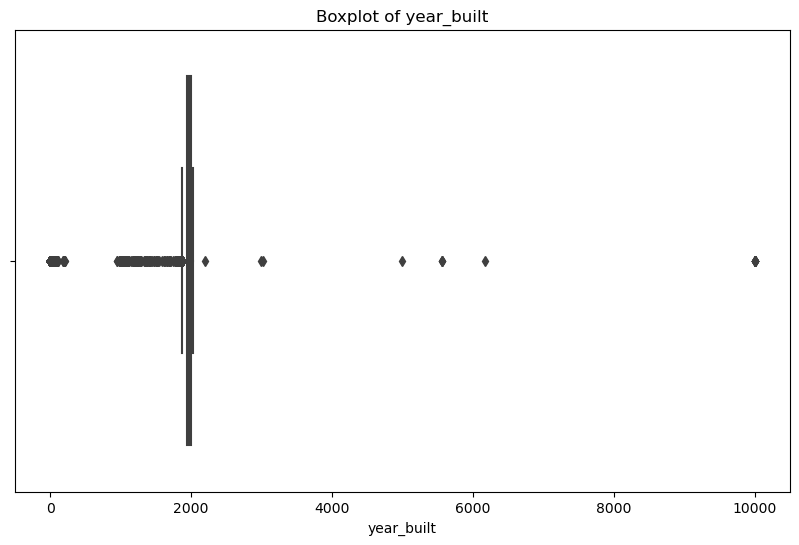

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cols_to_check = ['year_built']

for col in cols_to_check:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [23]:
data2['year_built'] = data2['year_built'].fillna(2000) #mode 

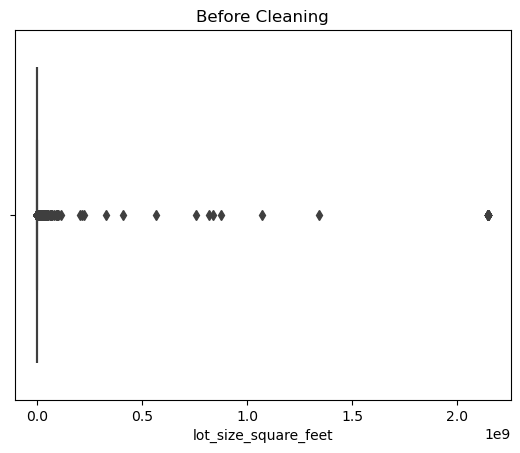

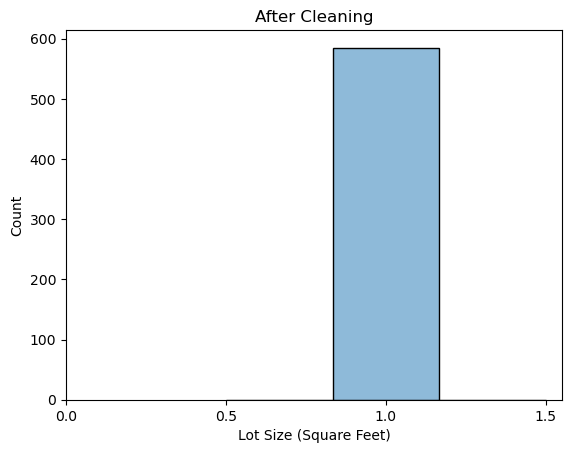

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

if 'lot_size_square_feet' in data2.columns:
    data2_cleaned = data2[(data2['lot_size_square_feet'] > 0) & (data2['lot_size_square_feet'] < 1.5)].copy()

    # Plot before cleaning
    sns.boxplot(data=data2[data2['lot_size_square_feet'] > 0], x='lot_size_square_feet')
    plt.title("Before Cleaning")
    plt.show()

    # Plot after cleaning
    histplot = sns.histplot(
        data2_cleaned['lot_size_square_feet'], 
        bins=int((1.5 - 0.0) / 0.5), 
        kde=True
    )
    plt.title("After Cleaning")
    plt.xlabel("Lot Size (Square Feet)")
    plt.xticks([0.0, 0.5, 1.0, 1.5]) 
    
    plt.show()
else:
    print("Column 'lot_size_square_feet' not found in data2.")

In [27]:
if 'lot_size_square_feet' in data2.columns:
    zero_lot_size = data2[data2['lot_size_square_feet'] == 0] #thường = 0 là có error
    
    print(data2.head(50))  
else:
    print("Column 'lot_size_square_feet' not found in data2.")

   status  list_price  sold_price  original_list_price  \
0    sold     19100.0       20154              19100.0   
1    sold    289900.0      274000             315000.0   
2    sold    109900.0      108900             269900.0   
3    sold     64500.0       60000             124900.0   
4    sold     90000.0       81000             269900.0   
5    sold    209900.0      209900             139900.0   
6    sold    105700.0      103500             139900.0   
7    sold     97900.0       91300             139900.0   
8    sold     59900.0       57500             139900.0   
9    sold     47500.0       43000             269900.0   
10   sold     67900.0       67000             139900.0   
11   sold    164900.0      164900             264900.0   
12   sold     76900.0       75000             269900.0   
13   sold     69900.0       67000             184071.0   
14   sold     44900.0       36500             269900.0   
15   sold     69900.0       66000             139900.0   
16   sold     

In [29]:
zero_lot_count = data2[(data2['lot_size_square_feet'] == 0) | (data2['lot_size_acres'] == 0)].shape[0]
total_count = data2.shape[0]
print(f"Rows with zero lot size: {zero_lot_count} out of {total_count}")

Rows with zero lot size: 911722 out of 1639775


In [31]:
import pandas as pd

data2['is_zero_lot_size'] = (data2['lot_size_square_feet'] == 0)

median_lot_size = data2.groupby('property_type')['lot_size_square_feet'].median()

data2['lot_size_square_feet'] = data2.apply(
    lambda row: median_lot_size[row['property_type']] if row['lot_size_square_feet'] == 0 else row['lot_size_square_feet'], axis=1
)

data2_cleaned = data2[~((data2['lot_size_square_feet'] == 0) & (data2['property_type'] == 'Detached Single'))]

print("Percent of zeros before cleaning:", (data2['is_zero_lot_size'].mean()) * 100)
print("Percent of zeros after cleaning:", ((data2_cleaned['lot_size_square_feet'] == 0).mean()) * 100)

Percent of zeros before cleaning: 0.3704166730191642
Percent of zeros after cleaning: 0.0


In [33]:
data2['lot_size_square_feet'] = data2['lot_size_square_feet'].fillna(1.0)

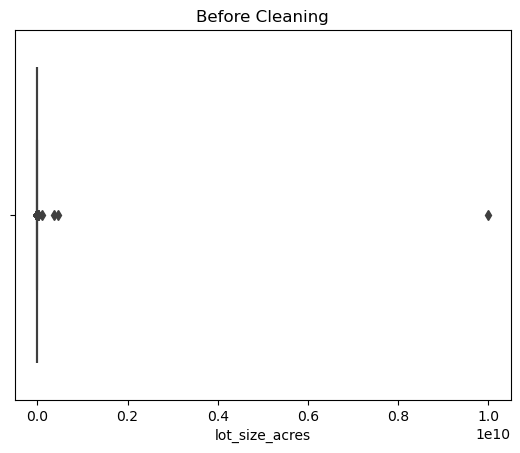

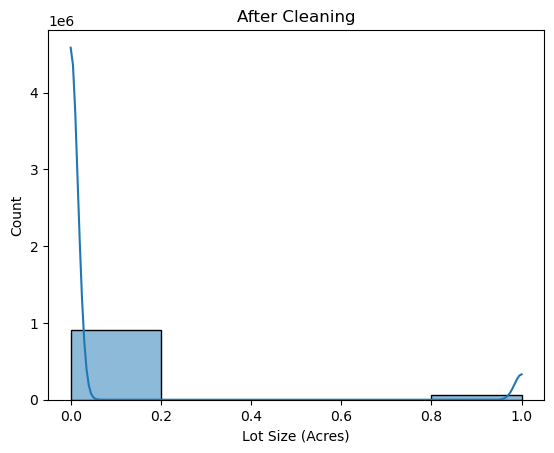

In [35]:
if 'lot_size_acres' in data2.columns:
    data2_cleaned = data2[data2['lot_size_acres'] <= 1.0].copy()

    # Plot before cleaning
    sns.boxplot(data=data2, x='lot_size_acres')
    plt.title("Before Cleaning")
    plt.show()

    # Plot after cleaning
    sns.histplot(
        data2_cleaned['lot_size_acres'], 
        bins=int((1.0 - 0.0) / 0.2),  # Bin size = 0.2
        kde=True
    )
    plt.title("After Cleaning")
    plt.xlabel("Lot Size (Acres)")
    plt.xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])  
    plt.show()
else:
    print("Column 'lot_size_acres' not found in data2.")

In [37]:
median_lot_size = data2['lot_size_acres'].median()
data2['lot_size_acres'].fillna(median_lot_size, inplace=True)

In [39]:
if 'hoa_fee' in data2.columns:
    hoa_fee_errors = data2[data2['hoa_fee'] >= 80000] #thường >=80000 là có error
    
    if not hoa_fee_errors.empty:
        print("Rows with 'hoa_fee' >= 80,000:")
        print(hoa_fee_errors)
    else:
        print("No rows found with 'hoa_fee' >= 80,000.")
else:
    print("Column 'hoa_fee' not found in data2.")

Rows with 'hoa_fee' >= 80,000:
           status  list_price  sold_price  original_list_price  \
343820       sold    798000.0      715000             812000.0   
671763       sold    360000.0      360000             360000.0   
1557941  inactive    565000.0      357000             565000.0   
1567607  inactive    540299.0      357000             540299.0   
1617794    active    571000.0      357000             571000.0   
1626343    active    546299.0      335000             546299.0   

         above_grade_square_feet  total_square_feet  finished_square_feet  \
343820                       0.0                0.0                   0.0   
671763                    1613.0                0.0                1613.0   
1557941                   3126.0                0.0                3126.0   
1567607                   3031.0                0.0                3031.0   
1617794                   3126.0                0.0                3126.0   
1626343                   3031.0            

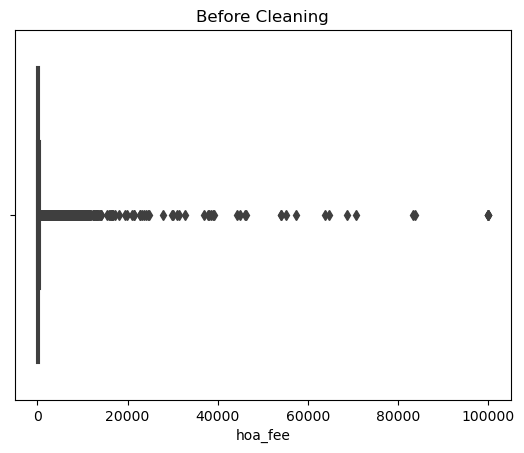

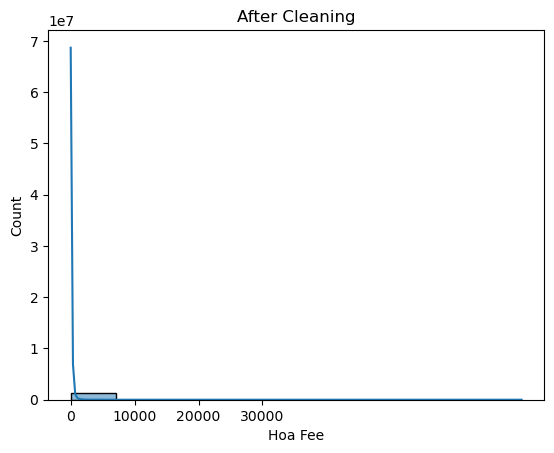

In [41]:
if 'hoa_fee' in data2.columns:
    data2_cleaned = data2[data2['hoa_fee'] < 80000].copy()

    # Plot before cleaning
    sns.boxplot(data=data2, x='hoa_fee')
    plt.title("Before Cleaning")
    plt.show()

    # Plot after cleaning
    sns.histplot(
        data2_cleaned['hoa_fee'], 
        bins=int((100000 - 0) / 10000),  
        kde=True
    )
    plt.title("After Cleaning")
    plt.xlabel("Hoa Fee")
    plt.xticks([0, 10000, 20000, 30000])  
    plt.show()
else:
    print("Column 'hoa_fee' not found in data2.")

In [43]:
data2['hoa_fee'] = data2['hoa_fee'].fillna(0.0) #mode

In [45]:
data2 = data2.dropna(subset=['structural_style', 'architecture', 'parcel_number', 'price_changes', 'county_data_id']) #style cannot be filled randomly/0/mean

columns=[
'photos', 'structural_style', 'property_type', 'architecture', 'year_built', 'lot_size_square_feet', 'lot_size_acres', 'lat', 'lng', 'listing_agent', 'listing_brokerage', 'structural_type', 'is_attached', 'stories', 'parcel_number', 'hoa_fee', 'price_changes', 'county_data_id'
]

# Check for NaN values in the specified columns
nan_counts = data2[columns].isna().sum()
print(nan_counts)

photos                  0
structural_style        0
property_type           0
architecture            0
year_built              0
lot_size_square_feet    0
lot_size_acres          0
lat                     0
lng                     0
listing_agent           0
listing_brokerage       0
structural_type         0
is_attached             0
stories                 0
parcel_number           0
hoa_fee                 0
price_changes           0
county_data_id          0
dtype: int64


In [47]:
data2.to_csv('cleaned_data.csv', index=False)

if 'city' in data2.columns:
    chicago_properties = data2[data2['city'].str.strip().str.lower() == 'chicago']
    
    if not chicago_properties.empty:
        chicago_properties.to_csv('chicago_properties.csv', index=False)
        print("Filtered data has been saved to 'chicago_properties.csv'.")
    else:
        print("No properties found in Chicago.")
else:
    print("Column 'city' not found in data2.")

Filtered data has been saved to 'chicago_properties.csv'.


In [49]:
chicago_properties = pd.read_csv('chicago_properties.csv')

columns_to_display = [
   'photos', 'structural_style', 'property_type', 'architecture', 'year_built', 'lot_size_square_feet', 'lot_size_acres', 'lat', 'lng', 'listing_agent', 'listing_brokerage', 'structural_type', 'is_attached', 'stories', 'parcel_number', 'hoa_fee', 'price_changes', 'county_data_id'
]

missing_columns = [col for col in columns_to_display if col not in chicago_properties.columns]
if missing_columns:
    print(f"The following columns are missing in the file: {missing_columns}")
else:
    print(chicago_properties[columns_to_display].head(100))

    photos structural_style    property_type       architecture  year_built  \
0        1          Cluster  Detached Single           Bungalow      1927.0   
1       13          Cluster  Detached Single           Cape Cod      1953.0   
2       15       1/2 Duplex  Detached Single              Ranch      1951.0   
3       16          Cluster  Detached Single           Bungalow      1924.0   
4       25            Condo  Detached Single            English      1955.0   
5       25            Condo  Detached Single       Contemporary      2014.0   
6       13       1/2 Duplex  Detached Single         Step Ranch      1952.0   
7       13          Cluster  Detached Single            Cottage         0.0   
8       18            Condo  Detached Single       Contemporary      1890.0   
9       19          Cluster  Detached Single           Cape Cod      1946.0   
10      21            Condo  Detached Single           Georgian         0.0   
11      24            Condo  Detached Single        

In [51]:
nan_ratio = chicago_properties.isna().sum() / len(chicago_properties) * 100  
total_nan = chicago_properties.isna().sum()
total_values = len(chicago_properties)  

nan_report = pd.DataFrame({
    'Total NaN Values': total_nan,
    'Total Rows': total_values,
    'NaN Percentage (%)': nan_ratio
})

nan_report = nan_report[nan_report['NaN Percentage (%)'] >= 75].sort_values(by='NaN Percentage (%)', ascending=False)

print("NaN Values Report (75% or more NaN values):")
display(nan_report)

NaN Values Report (75% or more NaN values):


,Total NaN Values,Total Rows,NaN Percentage (%)


In [53]:
# Drop the columns that seems to be unnecessary
chicago_properties = chicago_properties.copy()

chicago_properties.drop(
    columns=[
       "listing_agent", "listing_brokerage", "parcel_number"
    ], 
    errors='ignore',
    inplace=True
)

In [55]:
data2.to_csv('cleaned_chicago_properties.csv', index=False)
print("Cleaned_chicago_properties has been saved to 'cleaned_chicago_properties.csv'.")

Cleaned_chicago_properties has been saved to 'cleaned_chicago_properties.csv'.


In [57]:
data2.isna().sum()

status                     0
list_price                 0
sold_price                 0
original_list_price        0
above_grade_square_feet    0
total_square_feet          0
finished_square_feet       0
car_storage                0
garages                    0
beds                       0
baths                      0
area                       0
subdivision                0
street                     0
city                       0
state                      0
zip                        0
county                     0
photos                     0
structural_style           0
property_type              0
architecture               0
year_built                 0
lot_size_square_feet       0
lot_size_acres             0
lat                        0
lng                        0
listing_agent              0
listing_brokerage          0
structural_type            0
is_attached                0
stories                    0
parcel_number              0
hoa_fee                    0
price_changes 